In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# loadData
spx = pd.read_csv('../data/spx_raw.csv', index_col='Date', parse_dates=True)
vix = pd.read_csv('../data/vix_raw.csv', index_col='Date', parse_dates=True)
merged_df = pd.merge(spx, vix, left_index=True, right_index=True, how='inner')

**30 Day Realized Volatility**

### Step 1
**Daily Log Returns**

$$
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)
$$

- $P_t$ → today's closing price
- $P_{t-1}$ → yesterday's closing price

**Example:**

- $P_{t-1} = 5000$
- $P_t = 5050$

$$
\frac{5050}{5000} = 1.01
$$

$$
\ln(1.01) = 0.00995
$$

---
### Step 2
Take 30 day Rolling standard deviation
Example:
Returns series: $  [0.01, -0.01, 0.01, -0.01, ...]  $

Average $  = 0  $
$  \sigma = 1\%  $

Therefore:
Daily volatility = 1%

---

### Step 3
**Annualize using $\sqrt{\text{time}}$**

Variance scales with time. Volatility scales with the square root of time

$$
\sigma_{\text{annual}} = \sigma_{\text{daily}} \times \sqrt{252}
$$

$$
\text{volatility} = \sqrt{\text{variance}}
$$

**Example calculation:**

$$
0.01 \times \sqrt{252} = 0.158 \quad (15.8\%)
$$

In [3]:
import numpy as np

#  ln(P_t / P_{t-1})
merged_df['spx_log_ret'] = np.log(merged_df['spx_close'] / merged_df['spx_close'].shift(1))

# rollingStandardDeviation
merged_df['spx_roll_std'] = merged_df['spx_log_ret'].rolling(window=30).std()

# annualizeDailyVolatility
merged_df['spx_realized_vol'] = merged_df['spx_roll_std'] * np.sqrt(252)

# tail
merged_df[['spx_close', 'spx_log_ret', 'spx_roll_std', 'spx_realized_vol']].tail()

,spx_close,spx_log_ret,spx_roll_std,spx_realized_vol
Date,,,,
2026-05-29,7580.060059,0.002170,0.006477,0.102822
2026-06-01,7599.959961,0.002622,0.006224,0.098799
2026-06-02,7609.779785,0.001291,0.006168,0.097908
2026-06-03,7553.680176,-0.007399,0.006220,0.098740
2026-06-04,7584.310059,0.004047,0.006038,0.095845


### Unit Test: Volatility Calculation Verification (Bessel's Correction Check)
Bessel's correction improves the validity of a sample dataset.

Using an uncorrected n denominator slightly understates true population variance, so dividing by n-1 instead slightly inflates the final volatility estimate to better reflect true risk.

Correction factor shifts the denominator from n to n-1, and this adjustment matters less as sample size increases.

forward_realized_vol is shifted backward by 30 days so each row pairs a day's VIX forecast with its realized future outcome.


In [4]:
# 4. Programmatic sanity check (Adjusted for sample standard deviation)
import numpy as np

# Alternate +1% and -1% returns for a 30-day window
mock_returns = np.array([0.01, -0.01] * 15)

# Calculate sample standard deviation (ddof=1 to match pandas default)
mock_std = np.std(mock_returns, ddof=1)
mock_annualized_vol = mock_std * np.sqrt(252)

print(f"Mock Daily Return Std Dev: {mock_std * 100:.4f}%")
print(f"Mock Annualized Volatility: {mock_annualized_vol * 100:.2f}%")

# Expected volatility adjusted for N-1 degrees of freedom: 1% * sqrt(30 / 29) * sqrt(252)
expected_vol = 0.01 * np.sqrt(30 / 29) * np.sqrt(252)
print(f"Expected Volatility: {expected_vol * 100:.2f}%")

# Assert that the calculation matches the mathematical target
assert np.isclose(mock_annualized_vol, expected_vol), "Volatility calculation logic mismatch!"
print("Sanity check passed successfully!")

Mock Daily Return Std Dev: 1.0171%
Mock Annualized Volatility: 16.15%
Expected Volatility: 16.15%
Sanity check passed successfully!


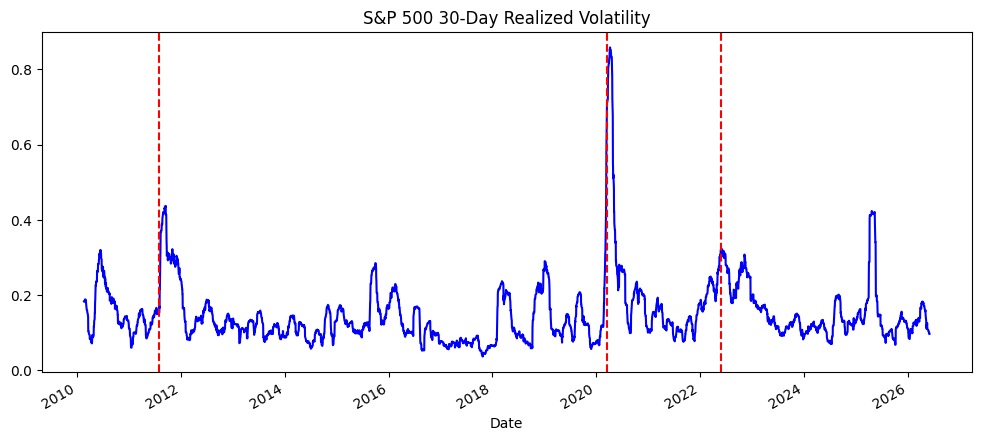

In [5]:
# plotRealizedData

merged_df['spx_realized_vol'].plot(figsize=(12, 5), title='S&P 500 30-Day Realized Volatility', color='blue')

plt.axvline(pd.to_datetime('2011-08-01'), color='red', linestyle='--')
plt.axvline(pd.to_datetime('2020-03-15'), color='red', linestyle='--')
plt.axvline(pd.to_datetime('2022-06-01'), color='red', linestyle='--')

<Axes: title={'center': 'Implied Volatility (VIX) vs. 30-Day Realized Volatility'}, xlabel='Date', ylabel='Volatility (Decimal)'>

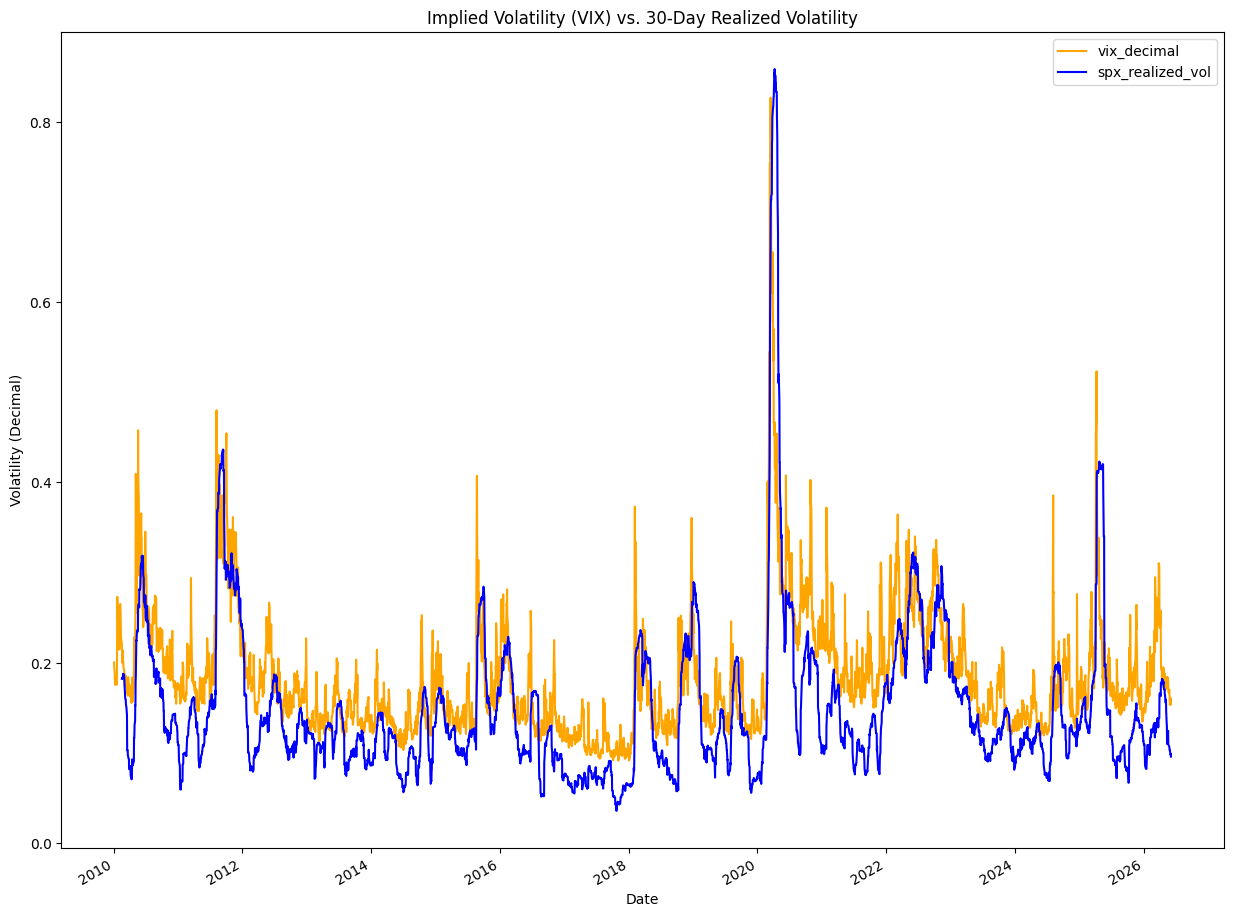

In [6]:
#plotTimeLine
merged_df['vix_decimal'] = merged_df['vix_close'] / 100

# plotRealizedvImplied
merged_df[['vix_decimal', 'spx_realized_vol']].plot(
    figsize=(15, 12),
    title='Implied Volatility (VIX) vs. 30-Day Realized Volatility',
    ylabel='Volatility (Decimal)',
    color=['orange', 'blue']
)


There are two observations to be made.

1. The VIX is a lot higher than the realized volatility. That is a premium people end up paying
2. Lagging Realized volatility: When a market shock occurs, VIX has an instant spike, but since the realized volatility looks back 30 days, it means it will take longer for the average to impact the result


**Alignment Shifting**

VIX calculates volatility based on the option prices for the next 30 days.
Realized volatility is based on the actual prices for the last 30 days.

In order to compare the accuracy of VIX's Forecast, we need to align the realized volatility with the calculated 30 days in the future.



In [7]:
# 1. Shift the realized volatility backwards by 30 trading days
# shiftThirty
merged_df['forward_realized_vol'] = merged_df['spx_realized_vol'].shift(-30)

# 2. dropFinalThirty
master_df = merged_df.dropna(subset=['forward_realized_vol']).copy()


master_dataset = master_df[['spx_close', 'vix_decimal', 'forward_realized_vol']]
master_dataset.to_csv('../data/master_dataset.csv')

print("Aligned master dataset exported successfully!")
print(f"Original rows: {len(merged_df)}")
print(f"New rows (should be exactly 30 fewer): {len(master_dataset)}")

Aligned master dataset exported successfully!
Original rows: 4130
New rows (should be exactly 30 fewer): 4100


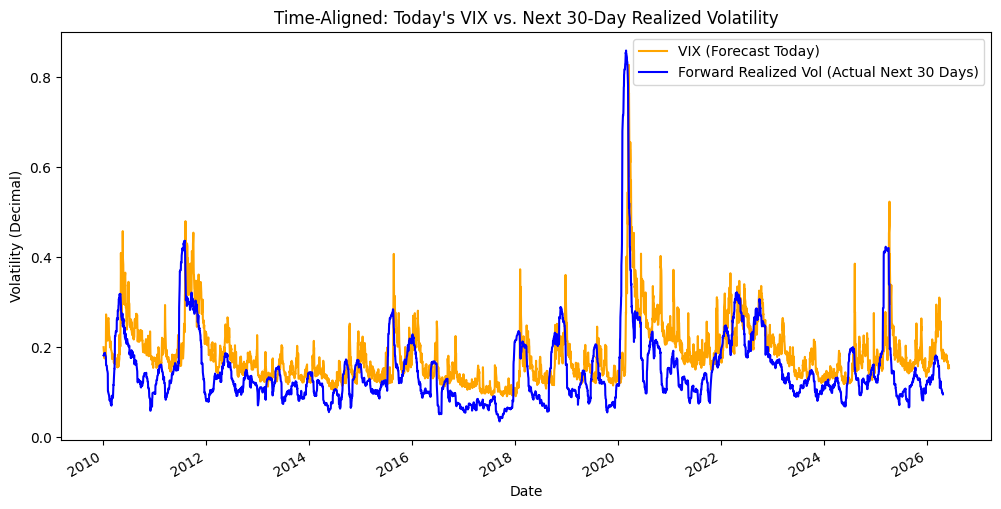

In [8]:
# 1. Shift the realized volatility backwards by 30 trading days
merged_df['forward_realized_vol'] = merged_df['spx_realized_vol'].shift(-30)

# 2. Scale VIX to match the decimal format of volatility
merged_df['vix_decimal'] = merged_df['vix_close'] / 100

# 3. Plot the aligned series
merged_df[['vix_decimal', 'forward_realized_vol']].plot(
    figsize=(12, 6),
    title='Time-Aligned: Today\'s VIX vs. Next 30-Day Realized Volatility',
    ylabel='Volatility (Decimal)',
    color=['orange', 'blue']
)
plt.legend(['VIX (Forecast Today)', 'Forward Realized Vol (Actual Next 30 Days)'])
plt.show()

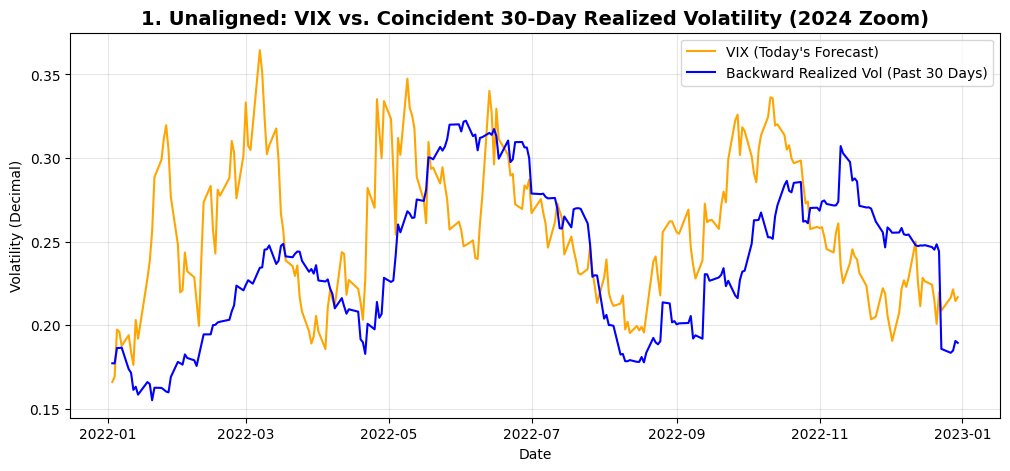

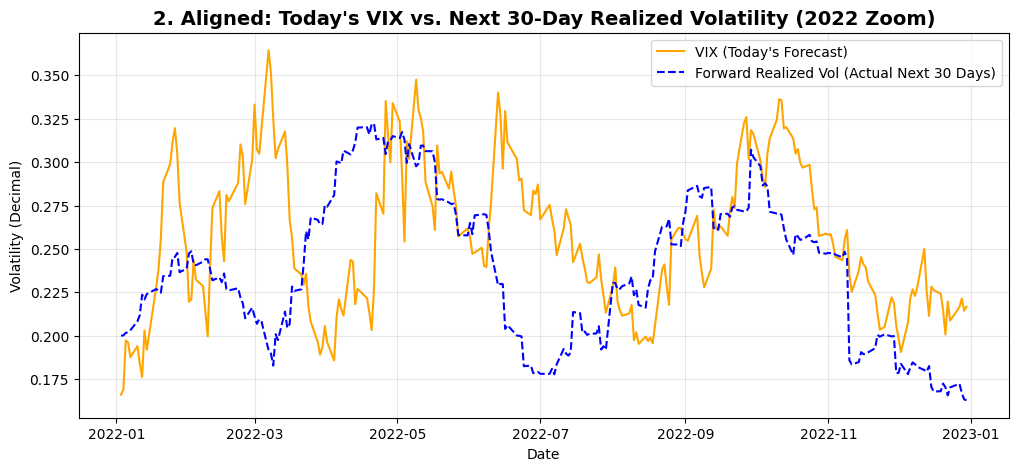

In [11]:
import matplotlib.pyplot as plt

# --- PREPARATION AND DATA SHIFTING ---
# 1. Scale VIX to decimal format
merged_df['vix_decimal'] = merged_df['vix_close'] / 100

# 2. Shift the realized volatility backwards by 30 trading days to align with today's VIX
merged_df['forward_realized_vol'] = merged_df['spx_realized_vol'].shift(-30)


# --- ZOOMING IN ON 2024 ---
# Filter the dataset for the year 2024
df_2024 = merged_df.loc['2022'].copy()


# --- GRAPH 1: UNALIGNED (Historical/Coincident View) ---
plt.figure(figsize=(12, 5))
plt.plot(df_2024.index, df_2024['vix_decimal'], color='orange', label='VIX (Today\'s Forecast)')
plt.plot(df_2024.index, df_2024['spx_realized_vol'], color='blue', label='Backward Realized Vol (Past 30 Days)')

plt.title('1. Unaligned: VIX vs. Coincident 30-Day Realized Volatility (2024 Zoom)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Volatility (Decimal)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()


# --- GRAPH 2: TIME-ALIGNED (Fair Match View) ---
plt.figure(figsize=(12, 5))
plt.plot(df_2024.index, df_2024['vix_decimal'], color='orange', label='VIX (Today\'s Forecast)')
# Notice we are plotting 'forward_realized_vol' here
plt.plot(df_2024.index, df_2024['forward_realized_vol'], color='blue', linestyle='--', label='Forward Realized Vol (Actual Next 30 Days)')

plt.title('2. Aligned: Today\'s VIX vs. Next 30-Day Realized Volatility (2022 Zoom)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Volatility (Decimal)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()